### This is some experimentation with SHAP and the iris-dataset

In [1]:
import xgboost
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import warnings
import xgboost as xgb
warnings.filterwarnings('ignore')

In [2]:
X, y = shap.datasets.iris()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
#model = RandomForestClassifier(random_state=42)
model = xgb.XGBClassifier(tree_method='gpu_hist', objective="multi:softproba", num_class=3)
model.fit(X_train, y_train)

,objective,'multi:softprob'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [4]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test, check_additivity=False)

print("shap_values.values.shape:", shap_values.values.shape)
# Typically (n_samples, n_classes, n_features) = (30, 3, 4) for Iris
print("X_test.shape:", X_test.shape)

shap_values.values.shape: (30, 4, 3)
X_test.shape: (30, 4)



--- Beeswarm for class 0 ---


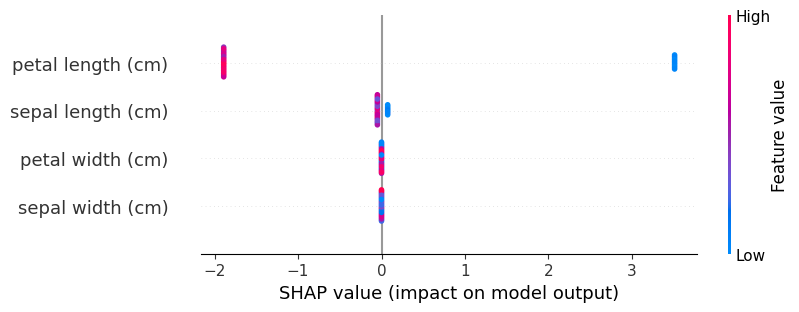


--- Beeswarm for class 1 ---


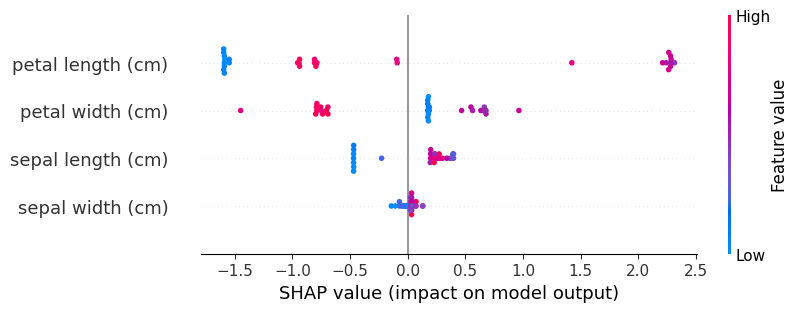


--- Beeswarm for class 2 ---


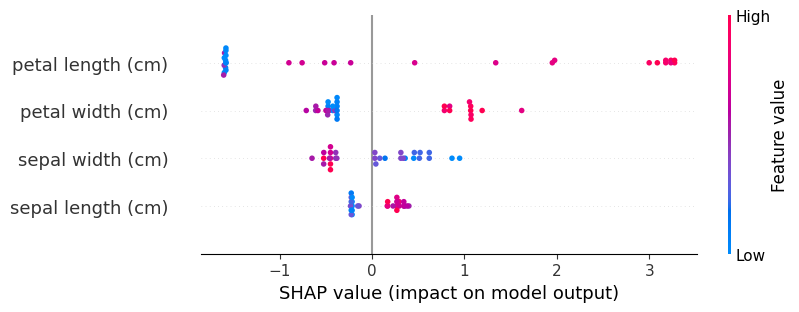

In [5]:
num_classes = shap_values.values.shape[1]
for class_idx in range(3):
    # Extract Explanation object for this class only
    shap_values_class = shap_values[..., class_idx]
    print(f"\n--- Beeswarm for class {class_idx} ---")
    shap.plots.beeswarm(shap_values_class)

In [6]:
X.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

### Feature interactions... try with different classes (based on how many classes your data has for target)

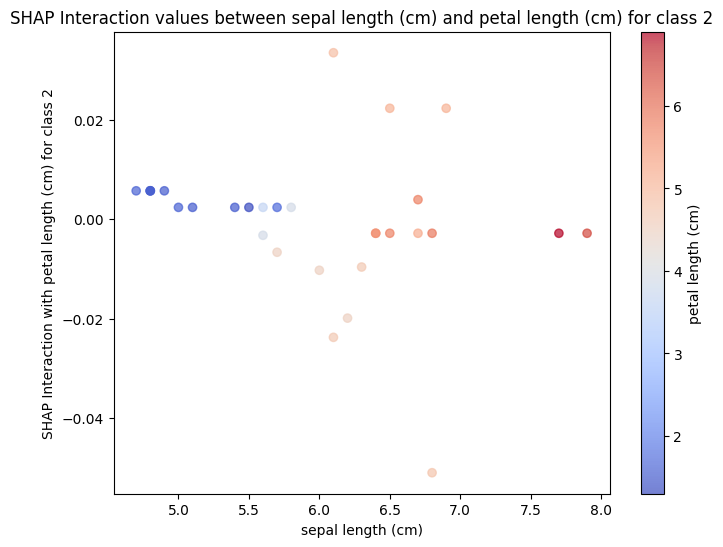

In [7]:
import matplotlib.pyplot as plt

feature_1 = 'sepal length (cm)'
feature_2 = 'petal length (cm)'
class_idx = 2  # class to inspect (0 to 4)

# # Use TreeExplainer specifically for XGBoost
explainer = shap.TreeExplainer(model)

feature_names = X_train.columns

# Subset X_test to these features to be sure of order
X_test_subset = X_test[feature_names]

# Get feature indices
i = feature_names.get_loc(feature_1)
j = feature_names.get_loc(feature_2)

shap_interaction_values = explainer.shap_interaction_values(X_test_subset)

# interaction array shape: (samples, feat1, feat2, classes)
# Pick class index on last axis
interaction_vals = shap_interaction_values[:, i, j, class_idx]

# Plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_test_subset[feature_1],  # x-axis: feature 1 values
    interaction_vals,          # y-axis: interaction SHAP values
    c=X_test_subset[feature_2],# color by feature 2 values
    cmap='coolwarm',
    alpha=0.7
)
plt.xlabel(feature_1)
plt.ylabel(f'SHAP Interaction with {feature_2} for class {class_idx}')
plt.colorbar(scatter, label=feature_2)
plt.title(f'SHAP Interaction values between {feature_1} and {feature_2} for class {class_idx}')
plt.show()
